# Stoer Group ca. 1199 Ma paleomagnetic pole

## Geologic context

The Stoer Group is the lowest of the three groups of the Mesoproterozoic "Torridonian" succession of NW Scotland (Stoer - Sleat - Torridon), a continental red-bed sequence of fluvial and lacustrine sandstones and mudstones deposited unconformably on Lewisian gneiss and beneath the Torridon Group unconformity. It contains the **Stac Fada Member**, a distinctive lapilli-bearing unit widely interpreted as proximal ejecta from a meteorite impact.

## Paleomagnetic data

The pole is the Lulea Working Group (2009) sample-weighted grand mean of six Stoer Group paleomagnetic studies - Stewart & Irving (1974), Smith et al. (1983), Torsvik & Sturt (1987, Stoer and Achiltibuie), Darabi & Piper (2004), and Borradaile & Geneviciene (2008) - as reported in the Evans et al. (2021) Laurentia compilation. The tilt-corrected mean direction is Dec 310.8 deg / Inc 34.7 deg, giving a pole at **37.2 deg N / 238.4 deg E (A95 = 7.7 deg)** from N = 610 samples, with mixed (normal + reverse) polarity.

## Age

A Pb-Pb date of 1199 +/- 70 Ma on lacustrine carbonate within the Stac Fada Member (Turnbull et al., 1996) and an Ar-Ar date of 1177 +/- 5 Ma on authigenic K-feldspar precipitated in degassing pipes associated with the impact ejecta (Parnell et al., 2011) constrain the Stac Fada Member, midway through the Stoer Group. Because the duration of deposition is unknown and the pole position appears to progress through the section, the rock age is uncertain; the pole is assigned **ca. 1199 Ma (1129-1269 Ma)** as in Evans et al. (2021).

A recently reported U–Pb age of 990 $\pm$ 22 Ma from three concordant analyses of granular domains in shocked zircon has instead been interpreted to date the Stac Fada impact and deposition of the middle Stoer Group placing it in the early Neoproterozoic \citep{Kirkland2025a}. However, many zircon analyses in that dataset are discordant and record variable Pb loss, raising the possibility that the 990 $\pm$ 22 Ma date does not represent the age of the impact. Resolving this chronostratigraphic uncertainty would allow the Stoer pole to provide a stronger constraint on the path.

## Reference frame

These rocks belong to the **Laurentia-Scotland** terrane: restoring the pole into the Laurentia reference frame requires an Euler rotation. The **Nordic summary below is exported in the unrotated, present-day Scottish coordinates** (applying the rotation to the compilation is left to downstream paleogeographic workflows). For assessment, the pole is shown below in **both** its unrotated and its rotated position, using the Scotland-to-Laurentia rotation of Torsvik & Cocks (2017) as tabulated by Swanson-Hysell (2021, Table 4.1): Euler pole 78.6°N / 161.9°E, rotation angle −31.0°.

## References

Paleomagnetic pole: Lulea Working Group mean (2009), as compiled in Evans et al. (2021). Age: Turnbull et al. (1996); Parnell et al. (2011).

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Pole from the Evans et al. (2021) compilation

The pole is read directly from the Evans et al. (2021) Laurentia compilation (`data/Evans_et_al_2021_compilation.csv`). No site-level recomputation is performed: this is the Lulea Working Group (2009) sample-weighted grand mean of the constituent studies, carried forward into the Nordic compilation format. The pole is reported in its published (unrotated, present-day Scottish) coordinates.

In [2]:
evans = pd.read_csv('../data/Evans_et_al_2021_compilation.csv')
row = evans[evans['ROCKNAME'] == 'MEAN Stoer Group'].iloc[0]

# published (unrotated, Scotland-frame) pole and mean direction
pole_mean = {'dec': float(row['PLONG']), 'inc': float(row['PLAT']),
             'alpha95': float(row['A95']), 'n': ''}     # grand mean: site count (B) left blank
dir_mean = {'dec': float(row['DEC']), 'inc': float(row['INC']),
            'alpha95': float(row['ED95']), 'k': float(row['KD'])}

print('MEAN Stoer Group pole (Evans et al., 2021 compilation; unrotated Scotland frame):')
print(f"  PLAT {pole_mean['inc']}  PLON {pole_mean['dec']}  A95 {pole_mean['alpha95']}  N {int(float(row['N']))} samples")
print(f"  mean direction Dec {dir_mean['dec']}  Inc {dir_mean['inc']}  (polarity: {row['%REV']})")

MEAN Stoer Group pole (Evans et al., 2021 compilation; unrotated Scotland frame):
  PLAT 37.2  PLON 238.4  A95 7.7  N 610 samples
  mean direction Dec 310.8  Inc 34.7  (polarity: MIXED)


## Statistical assessment (Meert et al., 2020; R2)

In [3]:
Laurentia_poles = pt.get_Laurentia_poles()
pt.R2_test('Stoer Group', Laurentia_poles)

N = 610 (N ≥ 25; sufficient sample number);
B = n/a (published grand mean of unit means; site number not reported);
K = 1000 (K ≥ 70; concern about underrepresenting PSV);


## Euler rotation into the Laurentia reference frame

The Scotland-to-Laurentia rotation of Torsvik & Cocks (2017) (Swanson-Hysell, 2021, Table 4.1) is applied with `pmag.pt_rot`: Euler pole 78.6 deg N / 161.9 deg E, angle -31.0 deg. This reproduces the rotated pole position carried in the project pole database.

In [4]:
euler_scotland = [78.6, 161.9, -31.0]   # [lat, lon, angle]; Torsvik & Cocks (2017)
rlat, rlon = pmag.pt_rot(euler_scotland, [pole_mean['inc']], [pole_mean['dec']])
pole_rotated = {'inc': rlat[0], 'dec': rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Scottish frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E")
print(f"rotated into the Laurentia frame:       {pole_rotated['inc']:.1f} N / {pole_rotated['dec']:.1f} E")

unrotated (present-day Scottish frame): 37.2 N / 238.4 E
rotated into the Laurentia frame:       31.8 N / 209.9 E


## Position within the Laurentia apparent polar wander path

The pole is shown in **separate** plots in its unrotated position (present-day Scottish coordinates, off the Laurentia path) and rotated into the Laurentia frame (restored onto the path).

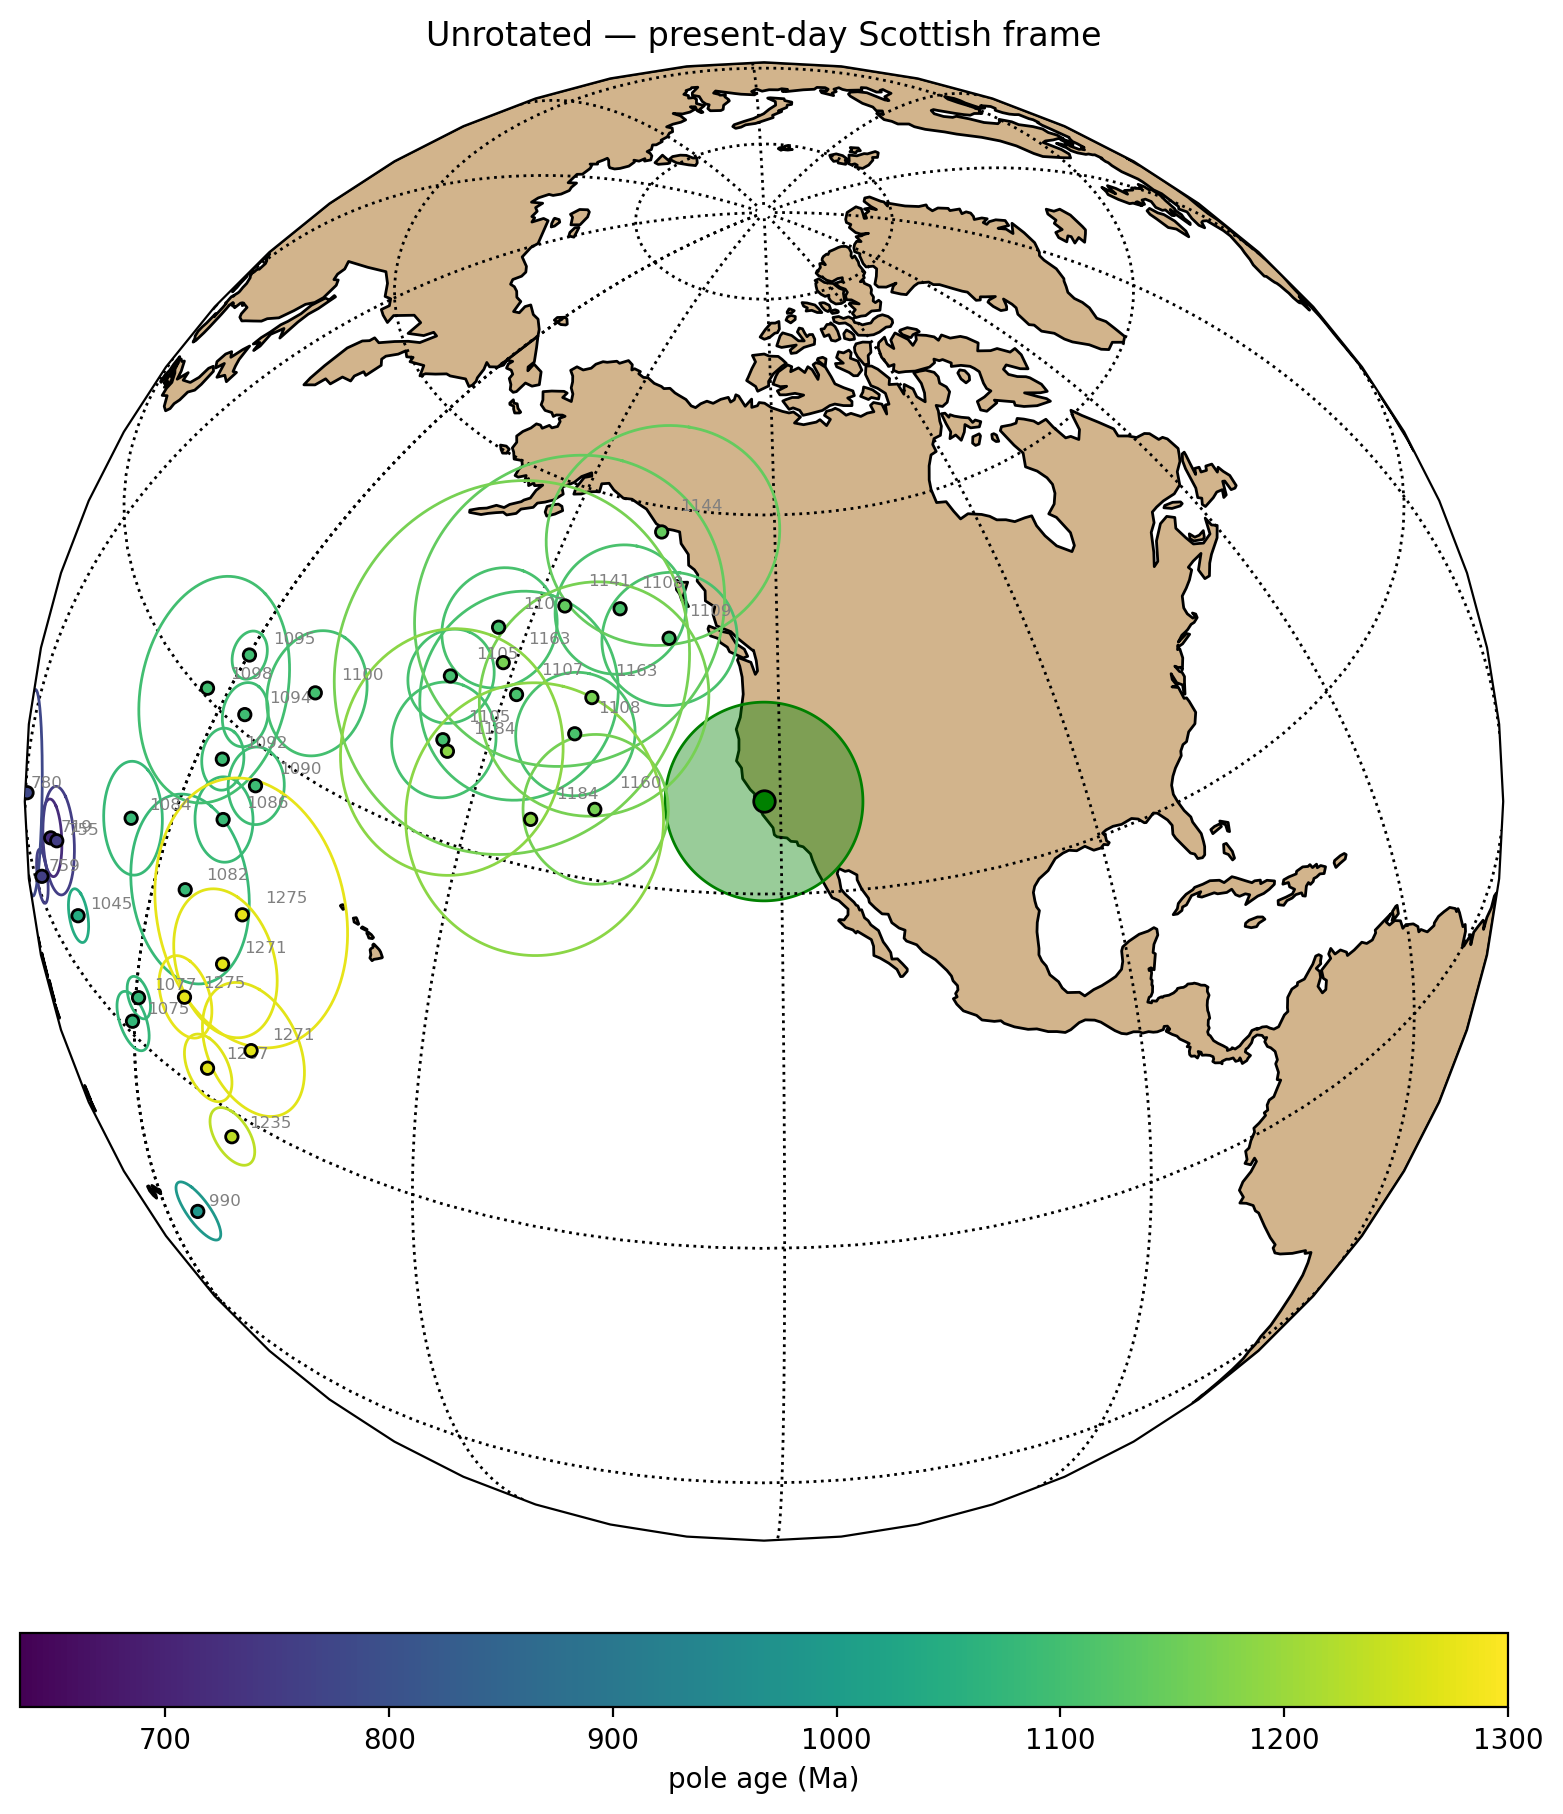

In [5]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1300,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.title('Unrotated — present-day Scottish frame')
plt.show()

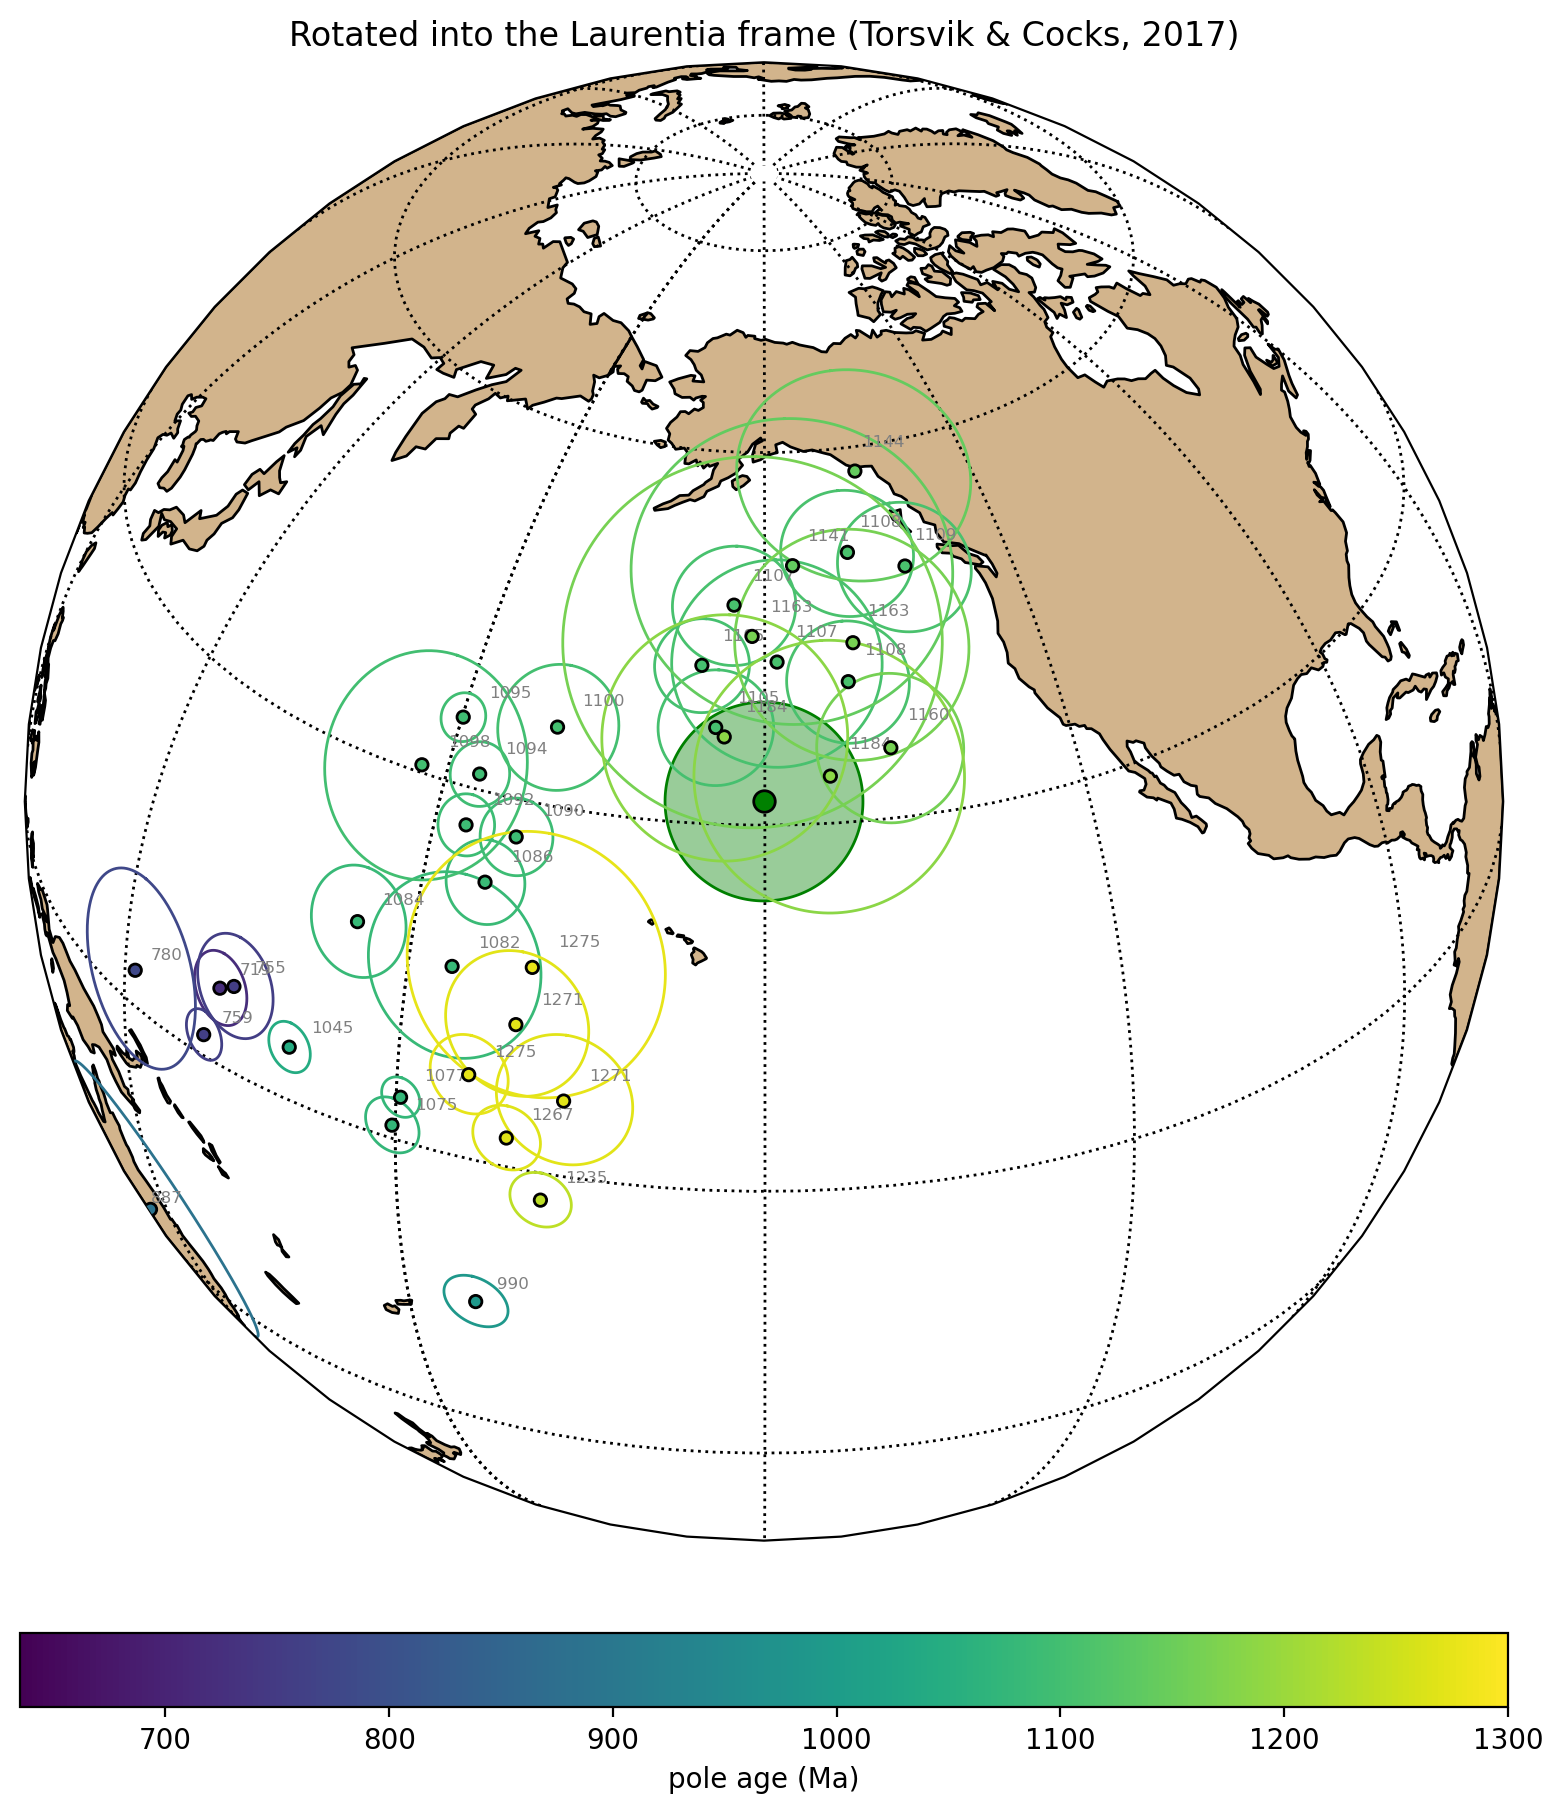

In [6]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_rotated['inc'], pole_rotated['dec'],
                          pole_rotated['alpha95'], age_min=635, age_max=1300,
                          projection='orthographic',
                          central_longitude=pole_rotated['dec'],
                          central_latitude=pole_rotated['inc'])
plt.title('Rotated into the Laurentia frame (Torsvik & Cocks, 2017)')
plt.show()

## Comparison with younger Laurentia poles

The same `plot_pole_overlap` comparison is shown for both positions.

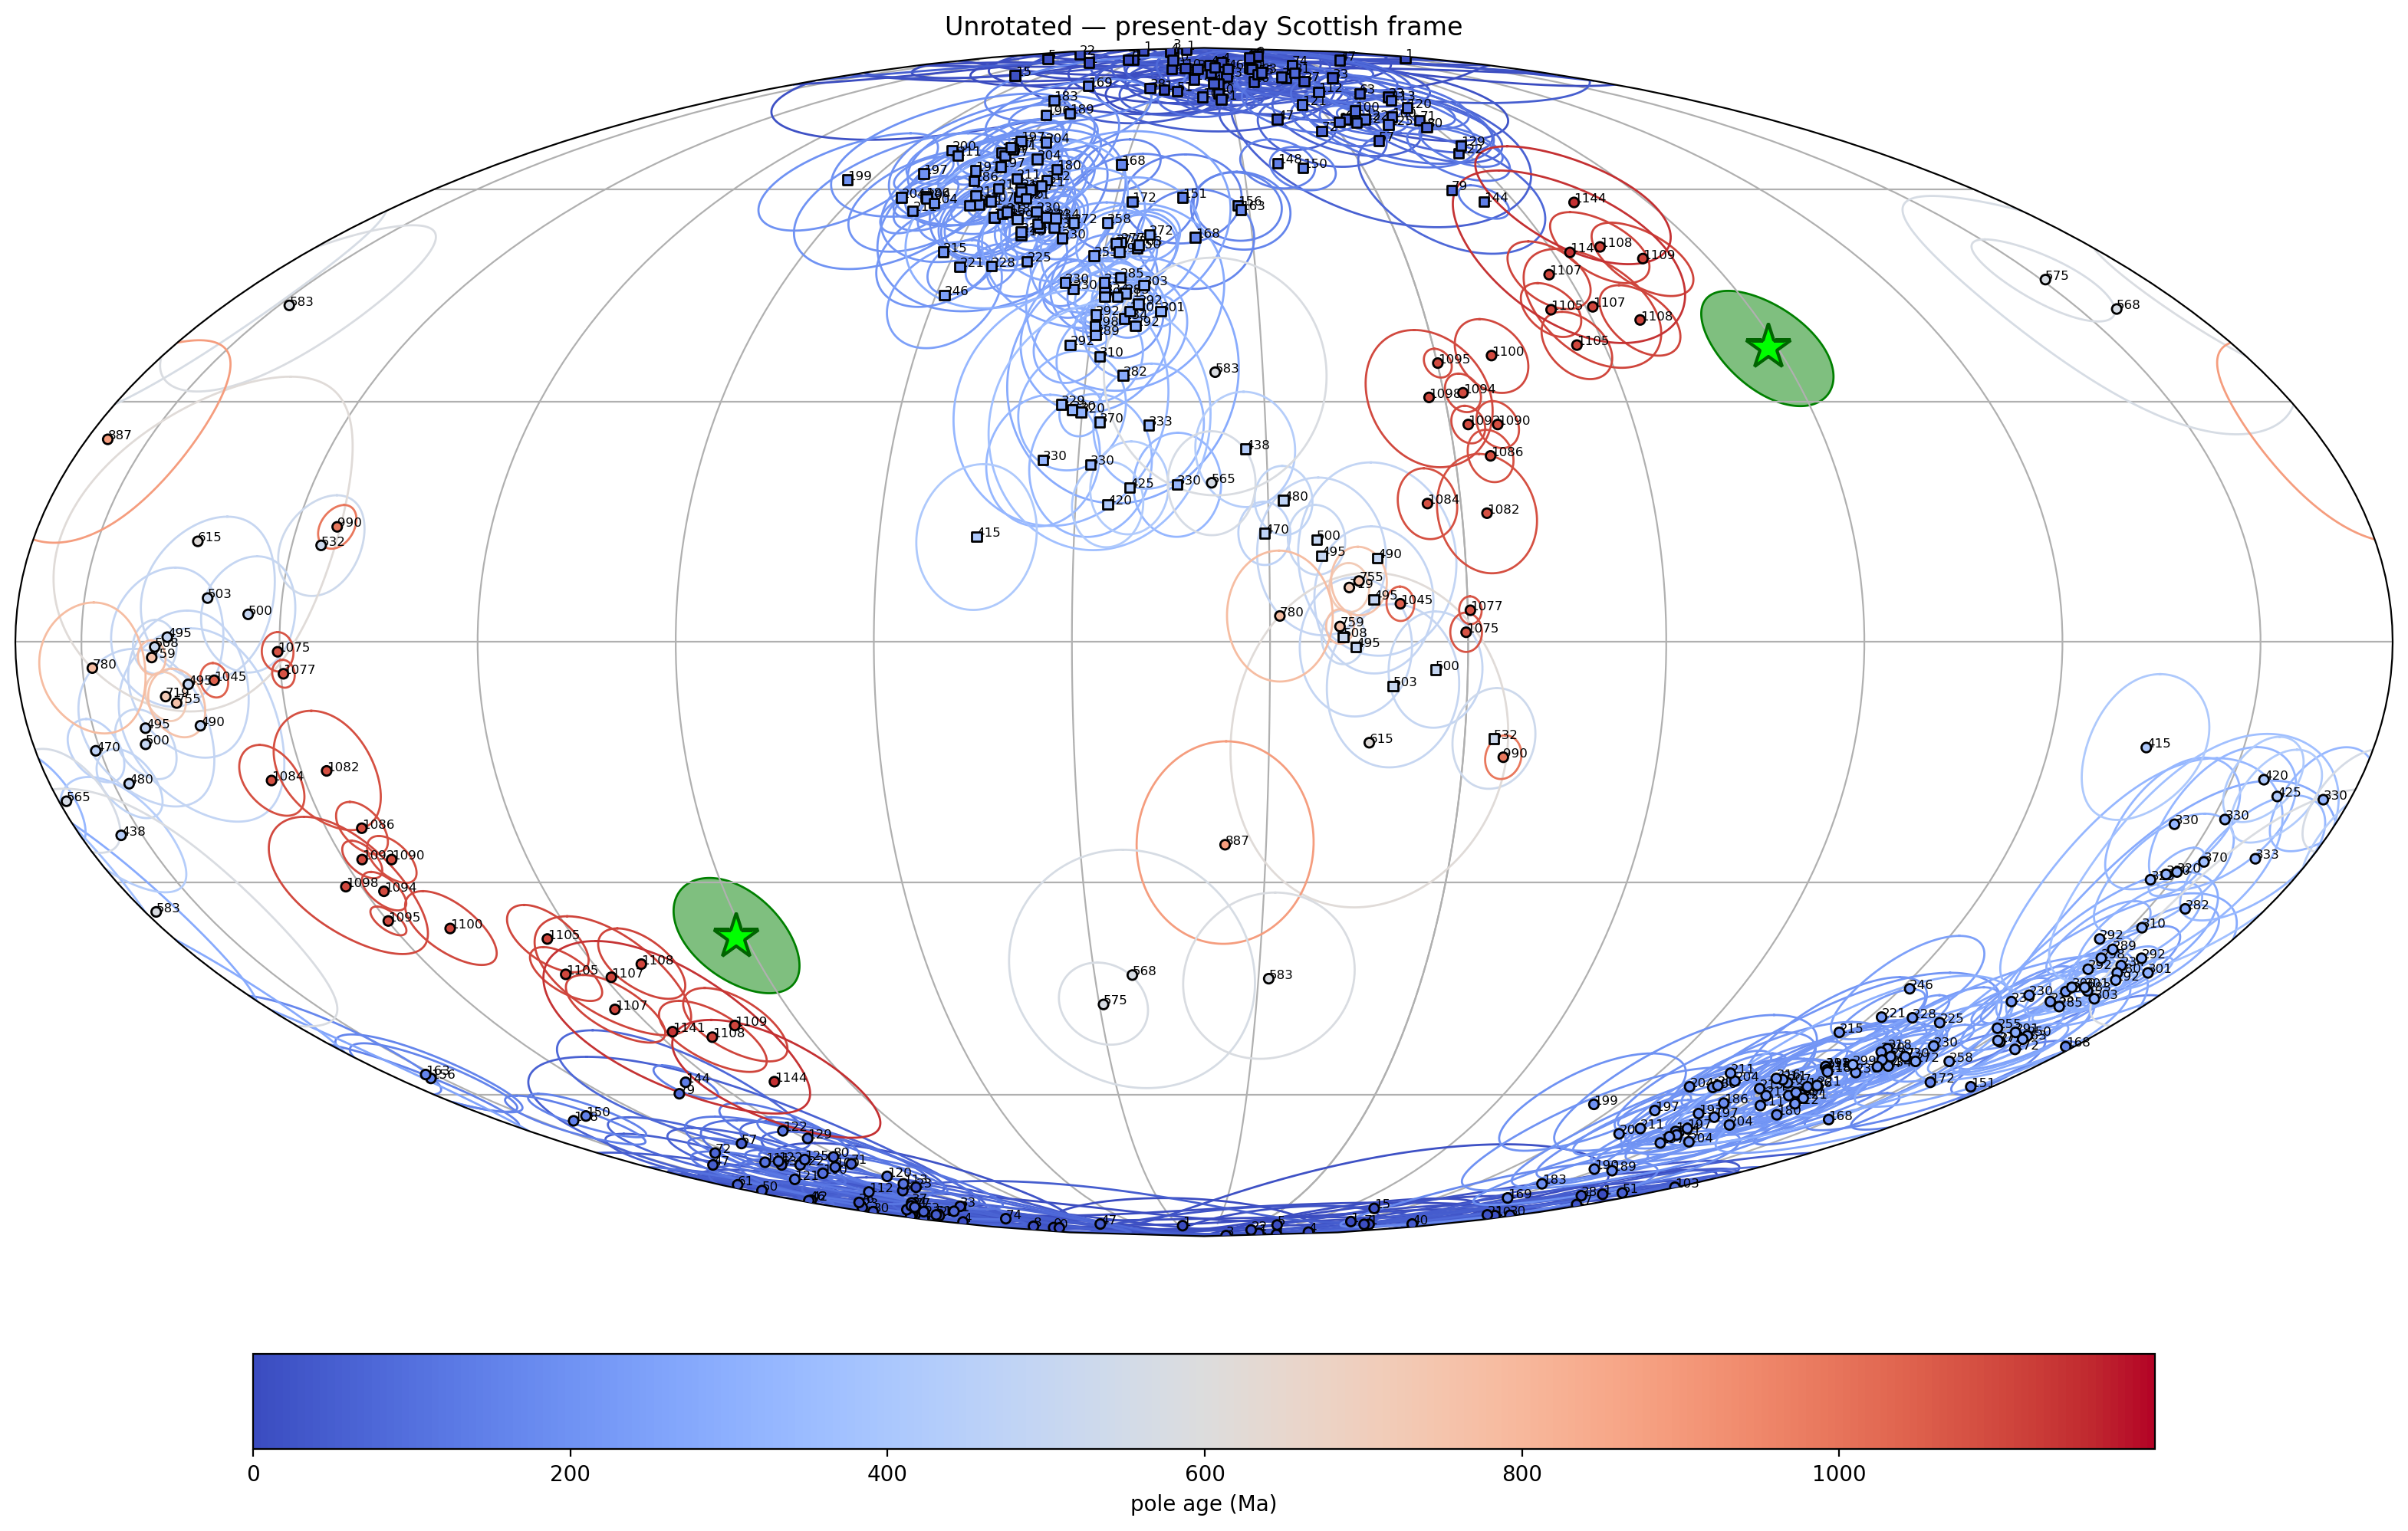

In [7]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('MEAN Stoer Group', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1199, show=False)
plt.title('Unrotated — present-day Scottish frame')
plt.show()

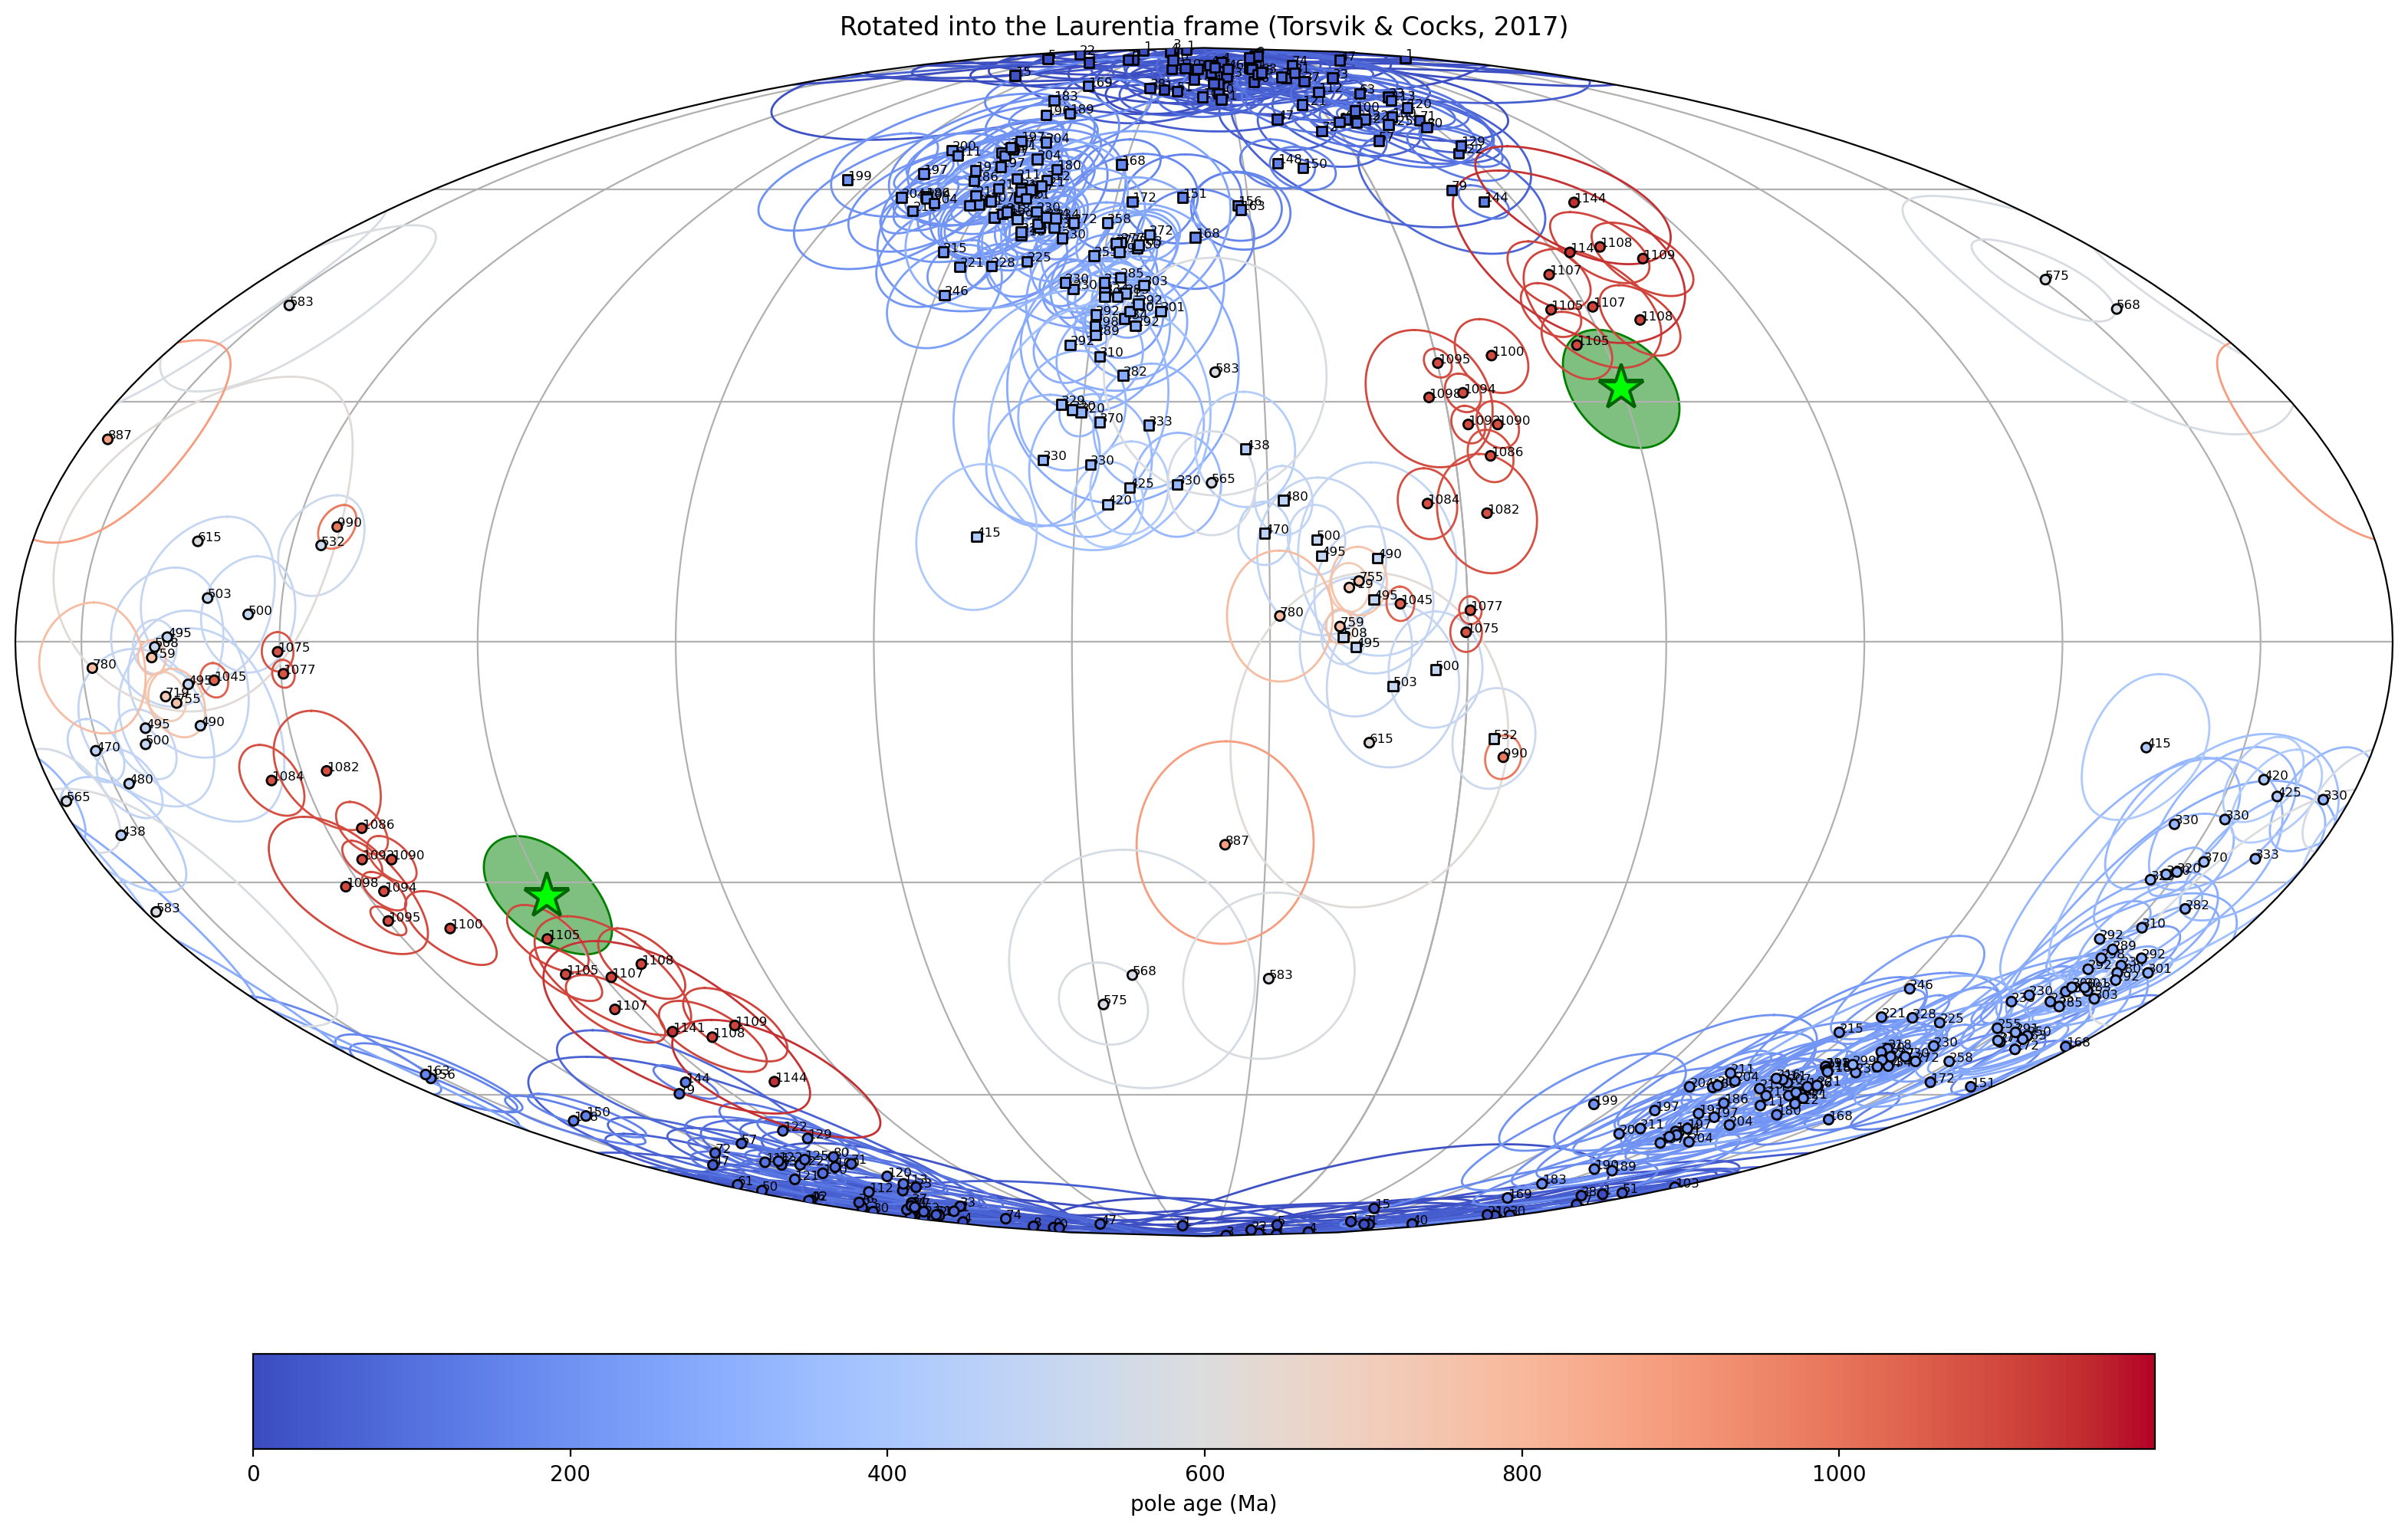

In [8]:
pt.plot_pole_overlap('MEAN Stoer Group', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rotated['inc'], pole_plon=pole_rotated['dec'],
                     pole_A95=pole_rotated['alpha95'], pole_age=1199, show=False)
plt.title('Rotated into the Laurentia frame (Torsvik & Cocks, 2017)')
plt.show()

## Nordic workshop summary

The pole is exported in the Nordic compilation format **without Euler rotation** (published Scottish coordinates). Because this is a published grand mean of unit means rather than a recomputed site-level pole, the site count (B) is left blank and the direction precision (KD = 1000, ED95 = 0.1) are the placeholder/sentinel values carried in the source compilation; the meaningful quantities are the pole position and A95.

In [9]:
# grand mean of unit means: one placeholder 'sites' row carrying the sample count + tilt state
row_sites = pd.DataFrame([{'dir_tilt_correction': int(float(row['TILT'])),
                           'dir_n_samples': int(float(row['N']))}])

summary = pt.make_nordic_summary(
    terrane='Laurentia-Scotland',
    rockname='Stoer Group',
    sites=row_sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=float(row['SLONG']),
    study_lat=float(row['SLAT']),
    component_comment='',
    tests='many',
    gpmdb_number='',
    magic_id='',
    percent_reversed='',          # source lists '%REV = MIXED' (dual polarity); see comment
    demag_code=int(float(row['DEMAGCODE'])),
    R1=0, R2=1, R3=1, R4='f',
    R5=0, R6=0, R7=1, Grade='B', Grade_E21='B',
    nominal_age=1199,
    lomagage=1129, himagage=1269,
    REF_method="A Pb-Pb date of 1199 +/- 70 Ma on lacustrine carbonate within the Stac Fada Member (Turnbull et al., 1996) and an Ar-Ar date of 1177 +/- 5 Ma on authigenic K-feldspar precipitated in degassing pipes associated with the impact ejecta (Parnell et al., 2011) constrain the Stac Fada Member, midway through the Stoer Group. Because the duration of deposition is unknown and the pole position appears to progress through the section, the rock age is uncertain; the pole is assigned **ca. 1199 Ma (1129-1269 Ma)**.",
    POLE_AUTHORS='Lulea Working Group mean (Evans et al., 2021 compilation)',
    YEAR=2009,
    JOURNAL='',
    VOLUME='',
    VPAGES='',
    TITLE='MEAN Stoer Group (Lulea Working Group grand mean)',
    COMMENT='Sample-weighted grand mean of six Stoer Group studies (Stewart & Irving 1974; Smith et al. 1983; Torsvik & Sturt 1987 Stoer + Achiltibuie; Darabi & Piper 2004; Borradaile & Geneviciene 2008); mixed (normal + reverse) polarity taken from the Evans et al. (2021) Laurentia compilation (Lulea Working Group six-study sample-weighted grand mean, 2009)'
)
pt.save_nordic_summary(summary, '1199_Stoer')
summary

,Terrane,ROCKNAME,GPMDB RESULT#,MAGIC #,COMPONENT,TESTS,TILT,SLAT,SLONG,B,...,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment,Lithology
0,Laurentia-Scotland,Stoer Group,,,,many,100,58.0,354.5,,...,A Pb-Pb date of 1199 +/- 70 Ma on lacustrine c...,Stoer Group,"Lulea Working Group mean (Evans et al., 2021 c...",2009,,,,MEAN Stoer Group (Lulea Working Group grand mean),Sample-weighted grand mean of six Stoer Group ...,


## Inclination-shallowing-corrected pole

The pole above is reported as measured. Detrital remanence in sedimentary rocks
is shallowed during compaction, so its inclination — and the paleolatitude that
inclination implies — is a minimum. This pole is a sample-weighted grand mean of six published studies rather than a single directional data set; the underlying distribution of directions is not available, so the flattening factor cannot be determined by elongation/inclination (E/I) or SVEI.

Following Pierce et al. (2022), the flattening factor is instead resampled from
their compilation of measured *f* values (`ipmag.find_compilation_kent`). Each
resample unsquishes the mean direction implied by the pole at the sampling
locality, and the resulting distribution of mean poles is summarized as a Kent
(1982) distribution whose 95% confidence ellipse carries the flattening
uncertainty along with the uncertainty in the pole itself. This corrected pole
is exported to `data/nordic_summaries/kent/` and is the position plotted for
this unit in the compilation figures; the main compilation table keeps the
uncorrected pole.

Plon: 246.1  Plat: 46.1
Major axis lon: 21.6  Major axis lat: 34.4
Minor axis lon: 129.0  Minor axis lat: 23.6
Major axis angle of 95% ellipse (Zeta): 14.8
Minor axis angle of 95% ellipse (Eta): 7.8
Number of directions in mean (n): 1000000


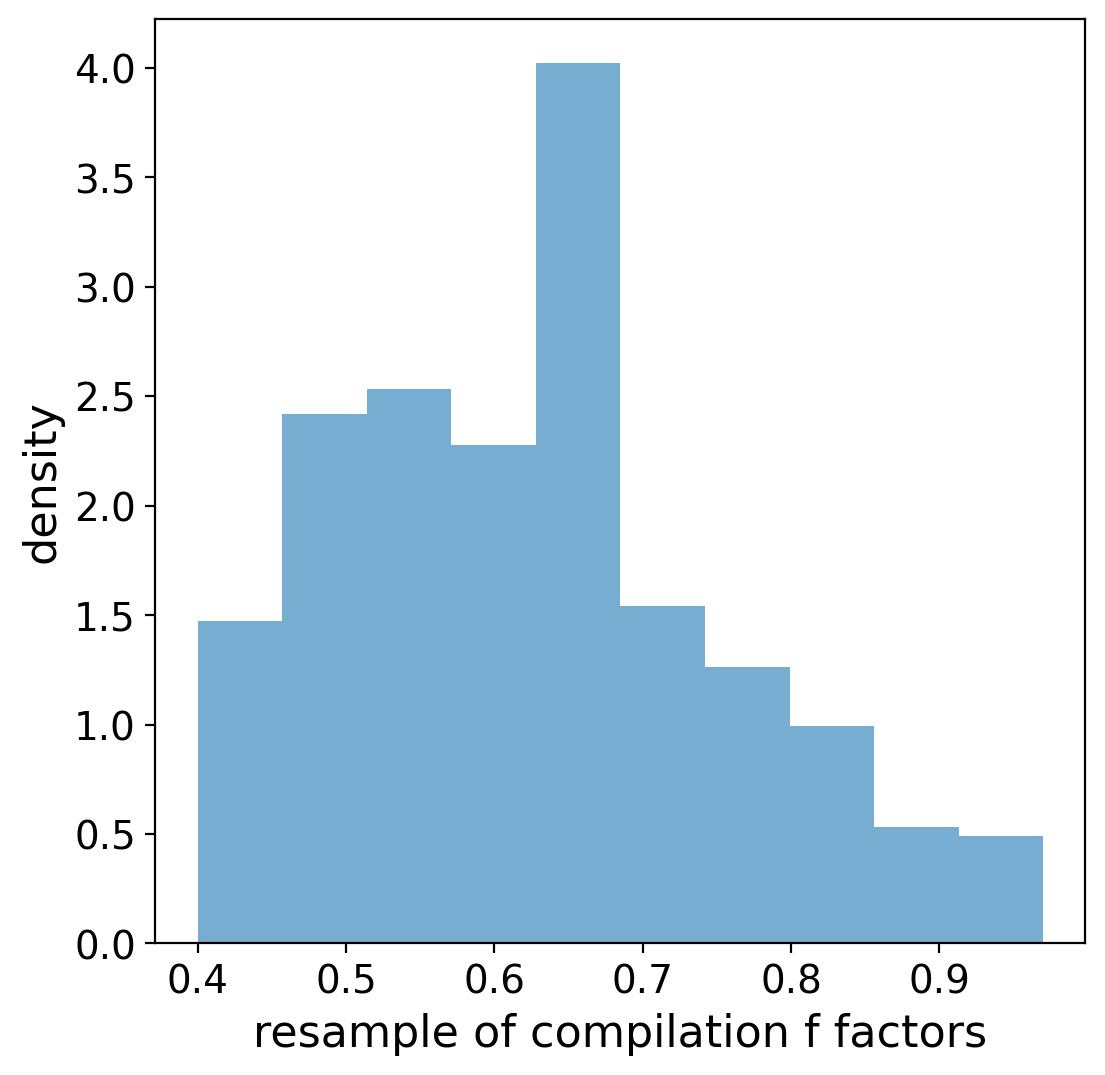

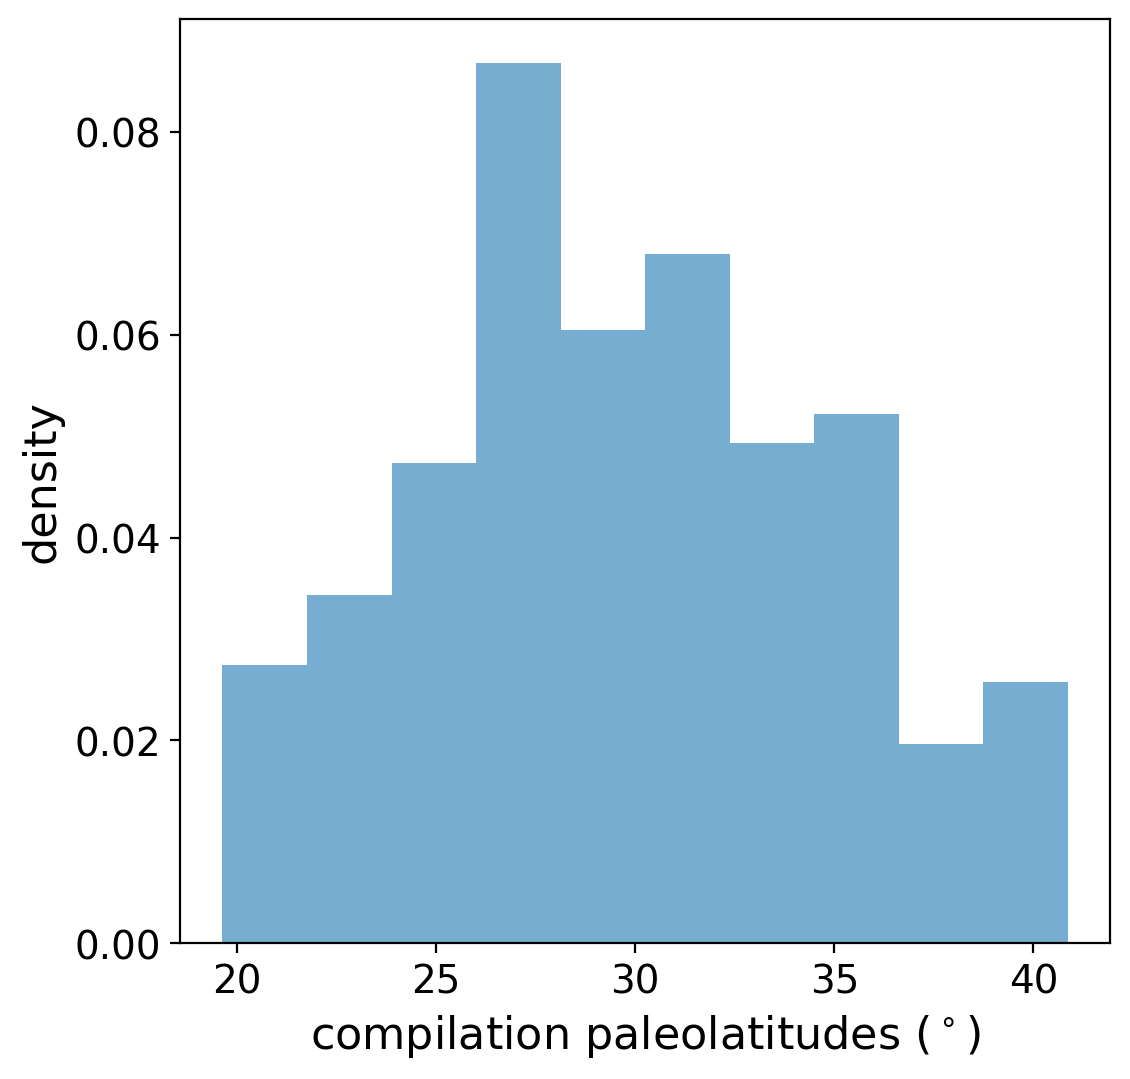

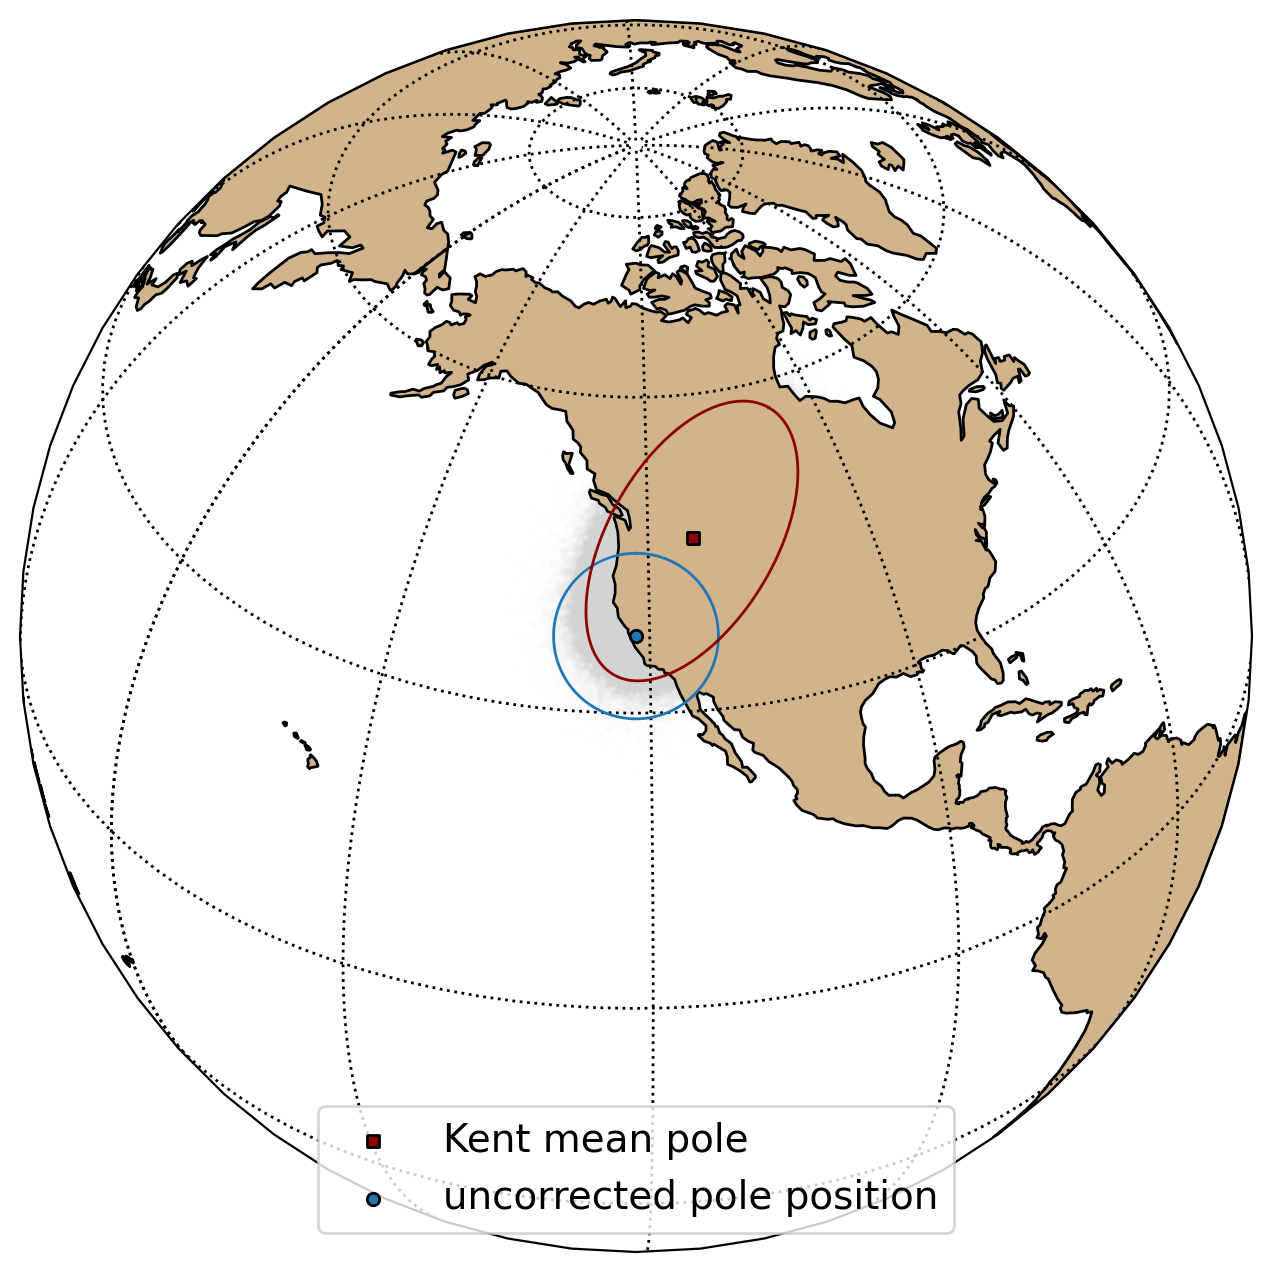

,Terrane,ROCKNAME,Lithology,SLAT,SLONG,nominal age,lomagage,himagage,Grade,f method,...,PLONG,Zdec,Zinc,Zeta,Edec,Einc,Eta,A95,n resampled,Comment
0,Laurentia-Scotland,Stoer Group,,58.0,354.5,1199,1129,1269,B,"compilation f (Pierce et al., 2022)",...,246.1,21.6,34.4,14.8,129.0,23.6,7.8,10.7,1000000,grand mean of six published studies; no direct...


In [10]:
# Inclination-shallowing-corrected Kent mean pole (Pierce et al., 2022). The
# random seed is fixed so the exported summary is reproducible.
kent = pt.compilation_kent_pole(pole_mean, float(row['SLONG']), float(row['SLAT']), random_seed=1)
plt.show()

stoer_kent_summary = pt.make_kent_summary(
    summary, kent, 'compilation', 'this study',
    comment='grand mean of six published studies; no directional distribution available for an E/I or SVEI determination of f')
pt.save_kent_summary(stoer_kent_summary, '1199_Stoer')
stoer_kent_summary